In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torch
import torch.distributions as td
import numpy as np
from flonacomldft.utils.io_utils import (
    get_path,
    load_zmat_csv,
    load_from_pickle,
    # save_pickle_file
)
from flonacomldft.utils.data_processing import get_mix_data
from flonacomldft.sampling import run_metropolis
from flonacomldft.models.mixture import Mixture
from flonacomldft.free_energy_computations import (
    compute_BAR, compute_TFP, compute_deepBAR_logratio, compute_TFP_logratio
    )

### Rechecking things on Gaussians

In [2]:
class MoG():
    def __init__(self, means, covars, weights=None,
                 dtype=torch.float32, device='cpu'):
        """
        Class to handle operations around mixtures of multivariate
        Gaussian distributions
        Args:
            means: list of 1d tensors of centroids
            covars: list of 2d tensors of covariances
            weights: list of relative statistical weights (does not need to sum to 1)
        """
        self.device = device
        self.beta = 1.  # model 'temperature' for sampling with langevin and mh
        self.means = means
        self.covars = covars
        self.dim = means[0].shape[0]
        self.k = len(means)  # number of components in the mixture

        if weights is not None:
            self.weights = torch.tensor(weights, dtype=dtype, device=device)
        else:
            self.weights = torch.tensor([1 / self.k] * self.k,
                                        dtype=dtype, device=device)

        self.cs_distrib = td.categorical.Categorical(probs=self.weights)
        self.normal_distribs = []
        for c in range(self.k):
            c_distrib = td.multivariate_normal.MultivariateNormal(
                self.means[c].to(device),
                covariance_matrix=self.covars[c].to(device)
                )
            self.normal_distribs.append(c_distrib)

        self.covars_inv = torch.stack([torch.inverse(cv) for cv in covars])
        self.dets = torch.stack([torch.det(cv) for cv in covars])

    def sample(self, n):
        cs = self.cs_distrib.sample_n(n).to(self.device)

        samples = torch.zeros((n, self.dim), device=self.device)
        for c in range(self.k):
            n_c = (cs == c).sum()
            samples[cs == c, :] = self.normal_distribs[c].sample_n(n_c)
        return samples.to(self.device)

    def log_prob(self, x):
        x = x.unsqueeze(1)
        m = torch.stack(self.means).unsqueeze(0)
        args = - 0.5 * torch.einsum('kci,cij,kcj->kc', x-m, self.covars_inv, x-m)
        args += torch.log(self.weights)
        args -= torch.log((self.weights.sum() * torch.sqrt((2 * np.pi) ** self.dim * self.dets)))
        return  torch.logsumexp(args, 1)
    
    def nll(self, x):
        return -self.log_prob(x)

sep = 2.
means = [torch.tensor([-sep, 0])] #, torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(2)] #,  2e-2 * torch.eye(2)]
means = [torch.tensor([-sep, 0])] #, torch.tensor([sep, 0])]
shift_means = [torch.tensor([-sep*0.8, 0])] #, torch.tensor([sep, 0])]

target = MoG(means, covars)
prop = MoG(shift_means, covars)

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/torch/functional.py:445: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /Users/distiller/project/conda/conda-bld/pytorch_1639180852547/work/aten/src/ATen/native/TensorShape.cpp:2157.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


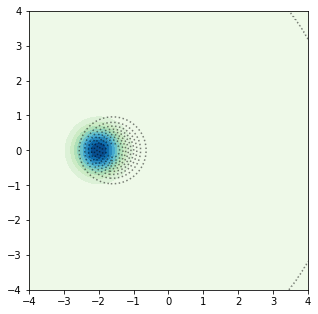

In [3]:
lims = {'x_min':-2 * sep, 'x_max':2 * sep, 'y_min':-2 * sep, 'y_max':2 * sep}
device = 'cpu'

def set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=prop.log_prob, lims=lims):
    
    x_range = torch.linspace(lims['x_min'], lims['x_max'], n_points, device=device)

    if lims['y_min'] is None:
        y_range = x_range.clone()
    else:
        y_range = torch.linspace(lims['y_min'], lims['y_max'], n_points, device=device)

    grid = torch.meshgrid(x_range, y_range)
    xys = torch.stack(grid).reshape(2, n_points ** 2).T.to(device)

    Us_target = target_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

    plt.figure() if ax is None else plt.sca(ax)
    plt.contourf(x_range, y_range, np.exp(Us_target), 10, cmap='GnBu')
    ax.set_aspect('equal')

    if prop_log_prob is not None:
        Us_prop = prop_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

        plt.contour(x_range, y_range, np.exp(Us_prop), 10, colors='k', linestyles=':', alpha=0.5)


plt.figure(figsize=(5,7))
# plt.suptitle()
ax = plt.subplot(1,1,1)
set_plot(ax)

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/torch/distributions/distribution.py:161: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)


logr_bar1:  2.9573302044715377 logr_err_bar1:  0.14581228733219065
logr_tfp1:  2.8923990086962217 logr_err_tfp1:  0.003265847649744021


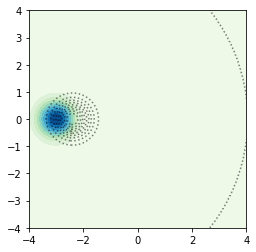

In [4]:
n_steps = 2
n_chains = 100

sep = 3.
means = [torch.tensor([-sep, 0])] #, torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(2)] #,  2e-2 * torch.eye(2)]
means = [torch.tensor([-sep, 0])] #, torch.tensor([sep, 0])]
shift_means = [torch.tensor([-sep*0.8, 0])] #, torch.tensor([sep, 0])]

target = MoG(means, covars)
prop = MoG(shift_means, covars)

plt.figure()
ax = plt.subplot(1,1,1)
set_plot(ax, target_log_prob=target.log_prob, prop_log_prob=prop.log_prob)

def mlp_is1(x):
    return - target.log_prob(x).view(-1, 1) + 3
    
flow_is1 = prop

xs1 = target.sample(n_chains)

logr_bar1, logr_err_bar1 = compute_BAR(xs1, target_log_prob=lambda x: - mlp_is1(x),
                                        prop=flow_is1)

n_prop = xs1.shape[0]
logr_tfp1, logr_err_tfp1 = compute_TFP(n_prop, 
                                        target_log_prob=lambda x: - mlp_is1(x),
                                        prop=flow_is1)

print('logr_bar1: ', logr_bar1, 'logr_err_bar1: ', logr_err_bar1)
print('logr_tfp1: ', logr_tfp1, 'logr_err_tfp1: ', logr_err_tfp1)

## 1.1 Shifting the overlap

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 7.154729209091215e-08 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 9.319392604845156e-09 reached.
  warnings.warn(msg, RuntimeWarning)


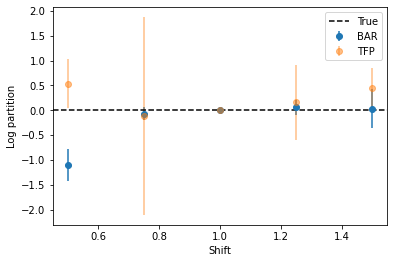

<Figure size 432x288 with 0 Axes>

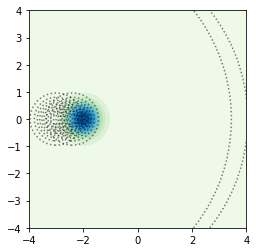

In [5]:
print("Warning: to this day I am not sure about the implementation the TFP var estimator")

sep = 2.
means = [torch.tensor([-sep, 0])] #, torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(2)] #,  2e-2 * torch.eye(2)]

shifts = torch.linspace(0.5, 1.5, 5)
logrs_bar = []
logr_errs_bar = []
logrs_tfp = []
logr_errs_tfp = []

xs = target.sample(10000)

for shift in shifts:
    shift_means = [torch.tensor([-sep * shift, 0])] #, torch.tensor([sep, 0])]

    target = MoG(means, covars)
    prop = MoG(shift_means, covars)

    def mlp_is1(x):
        return - target.log_prob(x).view(-1, 1)
    
    flow_is1 = prop

    xs1 = target.sample(n_chains)

    logr_bar1, logr_err_bar1 = compute_BAR(xs1, target_log_prob=lambda x: - mlp_is1(x),
                                            prop=flow_is1)

    n_prop = xs1.shape[0]
    logr_tfp1, logr_err_tfp1 = compute_TFP(n_prop, 
                                            target_log_prob=lambda x: - mlp_is1(x),
                                            prop=flow_is1)


    logrs_bar.append(logr_bar1)
    logr_errs_bar.append(logr_err_bar1)
    logrs_tfp.append(logr_tfp1)
    logr_errs_tfp.append(logr_err_tfp1)

plt.figure(1)
plt.errorbar(shifts, logrs_bar, yerr=logr_errs_bar, fmt='o', label='BAR')
plt.errorbar(shifts, logrs_tfp, yerr=logr_errs_tfp, fmt='o', label='TFP', alpha=0.5)
plt.axhline(0, color='k', linestyle='--', label='True')
plt.xlabel('Shift')
plt.ylabel('Log partition')
plt.legend()
plt.show(block=False)

plt.figure(2)
set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=prop.log_prob, lims=lims)


## Now checking the ratios

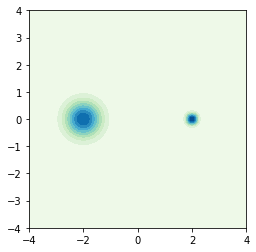

In [4]:
sep = 2.
means = [torch.tensor([-sep, 0]), torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(2),  2e-2 * torch.eye(2)]
weights = [0.9, 0.1]
target = MoG(means, covars, weights=weights)

plt.figure()
ax = plt.subplot(111)
set_plot(ax, n_points=1000, target_log_prob=target.log_prob, 
         prop_log_prob=None, lims=lims)

With perfect proposal: 

In [36]:
n_prop = 100
xs = target.sample(n_prop)
cs = (xs[:, 0] > 0) * 1.
target_log_prob = target.log_prob

cov_shift = 1.
shift_covars = [cov_shift * covars[0].clone(), cov_shift * covars[1].clone()]
prop = MoG(means, shift_covars, weights=torch.tensor([0.5, 0.5]))
mix_prop = [MoG(means[i:i+1], shift_covars[i:i+1], weights=torch.tensor([1.])) for i in range(2)]

logratio_bar, logratio_err_bar = compute_deepBAR_logratio(xs, cs, target_log_prob, mix_prop, n_prop=None)

logratio_tfp, logratio_err_tfp = compute_TFP_logratio(n_prop, target_log_prob, mix_prop)

print('logratio_bar: ', logratio_bar, 'logratio_err_bar: ', logratio_err_bar)
print('logratio_tfp: ', logratio_tfp, 'logratio_err_tfp: ', logratio_err_tfp)

print('expected ratio is {:0.2e}. Result bar: {:0.2e}, tfp: {:0.2e} errors:'.format(
    weights[1]/weights[0],
    np.exp(logratio_bar),
    np.exp(logratio_tfp)))

logratio_bar:  -2.1972245702115525 logratio_err_bar:  3.372130789694364e-08
logratio_tfp:  -2.1972248554229736 logratio_err_tfp:  9.053272452445117e-08
expected ratio is 1.11e-01. Result bar: 1.11e-01, tfp: 1.11e-01 errors:


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/torch/distributions/distribution.py:161: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)
/var/folders/36/k5151s2x247d1lg3fn_z91vr0000gn/T/ipykernel_22987/1520124790.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.weights = torch.tensor(weights, dtype=dtype, device=device)
/Users/marylou/Dropbox/Prof/Experiments/ml-dft/ML-DFT/packages/flonaco-ml-dft/flonacomldft/free_energy_computations.py:159: UserWarning: Error estimation misses ESS estimation
  warnings.warn("Error estimation misses ESS estimation")


In [38]:
n_prop = 1000
xs = target.sample(n_prop)
cs = (xs[:, 0] > 0) * 1.
target_log_prob = target.log_prob

cov_shift = 2
shift_covars = [cov_shift * covars[0].clone(), cov_shift * covars[1].clone()]
prop = MoG(means, shift_covars, weights=torch.tensor([0.5, 0.5]))
mix_prop = [MoG(means[i:i+1], shift_covars[i:i+1], weights=torch.tensor([1.])) for i in range(2)]

logratio_bar, logratio_err_bar = compute_deepBAR_logratio(xs, cs, target_log_prob, mix_prop, n_prop=None)

logratio_tfp, logratio_err_tfp = compute_TFP_logratio(n_prop, target_log_prob, mix_prop)

print('logratio_bar: ', logratio_bar, 'logratio_err_bar: ', logratio_err_bar)
print('logratio_tfp: ', logratio_tfp, 'logratio_err_tfp: ', logratio_err_tfp)

print('expected ratio is {:0.2e}. Result bar: {:0.2e}, tfp: {:0.2e}'.format(
    weights[1]/weights[0],
    np.exp(logratio_bar),
    np.exp(logratio_tfp)))

logratio_bar:  -2.1166124661206442 logratio_err_bar:  0.07305075234721402
logratio_tfp:  -2.182490825653076 logratio_err_tfp:  0.1548064892938051
expected ratio is 1.11e-01. Result bar: 1.20e-01, tfp: 1.13e-01


/var/folders/36/k5151s2x247d1lg3fn_z91vr0000gn/T/ipykernel_22987/1520124790.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.weights = torch.tensor(weights, dtype=dtype, device=device)
